In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate_total(parameters):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    t_span = 400  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# Define how populations evolve
def simulate(parameters, observation):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation):
    latent = simulate_match_data(parameters, n_obs,observation)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation):
    latent = simulate_match_data(parameters, n_obs, observation)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.1,   # alpha - 1.6
        0.02,   # beta - 3.2
        0.015,  # delta - 0.6
        0.08    # gamma - 0.56
    ]))

    log_stds = torch.tensor([0.3, 0.3, 0.3, 0.3])

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 150], [0, 25], [0, 50]],
        figsize=(4, 4),
    )


In [16]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior = inference.build_posterior(sample_with="mcmc")
    samples = posterior.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            points = true_val[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior, inference

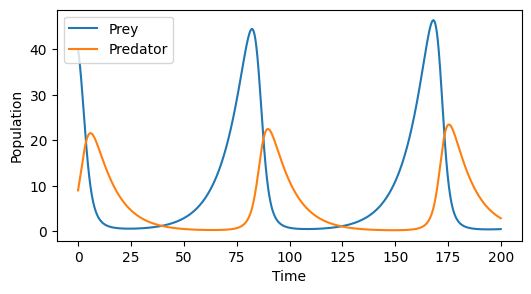

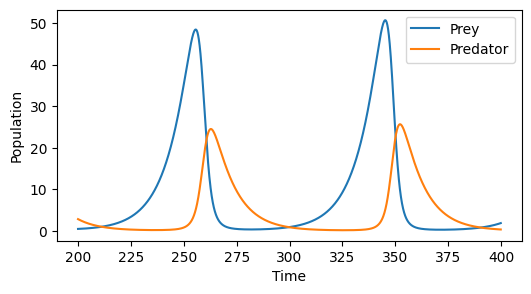

In [2]:
time_vec = np.arange(0, 400, 0.1)
true_parameters = np.asarray([0.1, 0.02, 0.01, 0.1])

observation = simulate_total(true_parameters)

time1, time2 = split_in_two(time_vec)
obs1, obs2 = split_in_two(observation)

plot_observed_data(time1, obs1)
plot_observed_data(time2, obs2)





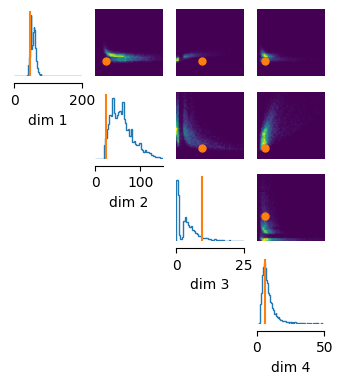

In [7]:
sigma_hare1 = 0.2 * np.std(obs1[:, 0])   # 20% of hare std
sigma_lynx1 = 0.2 * np.std(obs1[:, 1])   # 20% of lynx std
sigma_hare2 = 0.2 * np.std(obs2[:, 0])   # 20% of hare std
sigma_lynx2 = 0.2 * np.std(obs2[:, 1])   # 20% of lynx std
n_obs1 = len(obs1)
n_obs2 = len(obs2)

prior_name = 'uniform' #prior = 'logn'
noise1 =   'poisson' #'gaussian' 'none'
noise2 = 'gaussian'
max_epoch = 150

prior1,theta1 = choose_prior_and_generate_theta(prior_name)
x1 = generate_x(theta1,noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1)
x_obs1 = summarize_simulation(obs1)
plot_checker(x1,x_obs1)



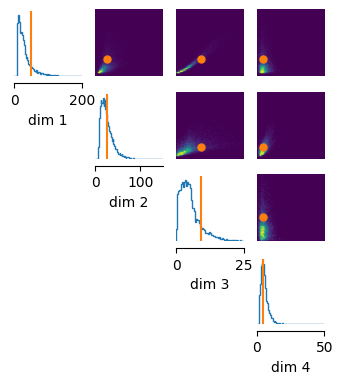

In [8]:
prior2,theta2 = choose_prior_and_generate_theta(prior_name)
x2 = generate_x(theta2,noise2, n_obs2, sigma_hare2, sigma_lynx2, obs2)
x_obs2 = summarize_simulation(obs2)
plot_checker(x2,x_obs2)

In [1]:
samples1, posterior1, inference1 = train_net_generate_samples(x1,theta1,x_obs1, prior1, verbose = True, max_epoch=max_epoch, true_val=true_parameters)

NameError: name 'train_net_generate_samples' is not defined

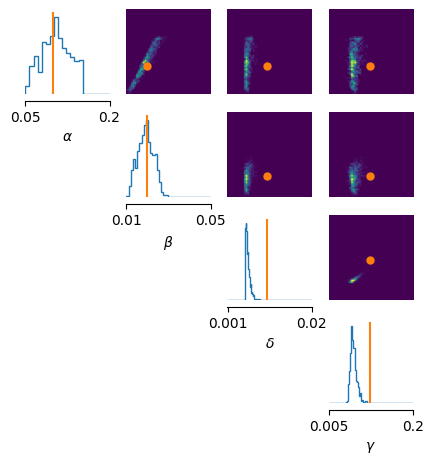

In [23]:
_ = pairplot(
            samples1,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

 Training neural network. Epochs trained: 151

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\Lotka-Volterra\sbi-logs\NPE_C\2025-11-26T12_40_32.574756' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  [50.70120241 25.67033738  9.0473619   4.61293963]


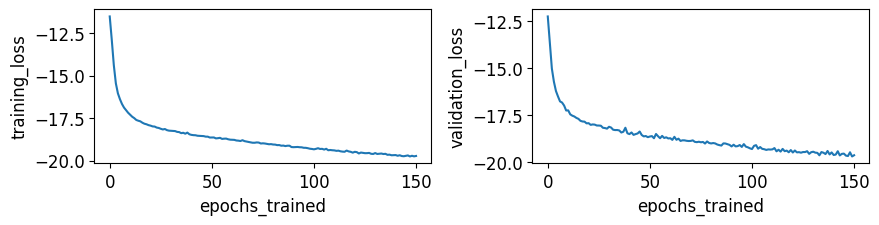

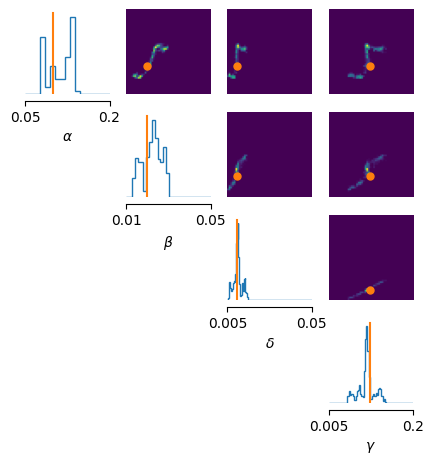

In [17]:
samples2, posterior2, inference2 = train_net_generate_samples(x2,theta2,x_obs2, prior2, verbose = True, max_epoch=max_epoch, true_val=true_parameters)

In [25]:
from scipy.stats import gaussian_kde
from scipy.special import rel_entr

def compute_kl_divergence(samples_p, samples_q):
    kde_p = gaussian_kde(samples_p.T)
    kde_q = gaussian_kde(samples_q.T)
    points = samples_p.T
    p_vals = kde_p(points)
    q_vals = kde_q(points)
    kl_div = np.sum(rel_entr(p_vals, q_vals))
    return kl_div

compute_kl_divergence(samples1[:,0].reshape(-1,1),samples2[:,0].reshape(-1,1))


np.float64(4535.533754464899)

In [28]:
from scipy.stats import gaussian_kde, entropy
import numpy as np

def stable_kl_1d(samples_p, samples_q, num_points=1000):
    kde_p = gaussian_kde(samples_p)
    kde_q = gaussian_kde(samples_q)

    xmin = min(samples_p.min(), samples_q.min())
    xmax = max(samples_p.max(), samples_q.max())
    x_eval = np.linspace(xmin, xmax, num_points)

    p_vals = kde_p(x_eval)
    q_vals = kde_q(x_eval)

    # Avoid division by zero / log(0)
    p_vals += 1e-12
    q_vals += 1e-12

    # Normalize
    p_vals /= np.sum(p_vals)
    q_vals /= np.sum(q_vals)

    return entropy(p_vals, q_vals)

for i, name in enumerate(["α", "β", "δ", "γ"]):
    kl_val = stable_kl_1d(samples1[:, i], samples2[:, i])
    print(f"KL({name}) = {kl_val:.3f}")


KL(α) = 0.582
KL(β) = 0.339
KL(δ) = 3.151
KL(γ) = 1.719
